CNN Classification Script
==================
This script trains a binary image classifier using a fine-tuned ResNet-18 model in PyTorch, with data loading, augmentation, and model saving included.

To Use with a Different Dataset or Save Location, Change These:

1. Dataset path:
   Change the root folder where your training/validation images are stored:
   data_dir = './output'  # ← change this to your dataset folder

3. Subfolder names (if different):
   If your dataset uses different folder names than 'train' and 'val', update:
   for x in ['train', 'val']  # ← change to match your dataset split names
   and also update data_transforms = { 'train': ..., 'val': ... }

4. Save location for models:
   Change the file paths where the model and weights will be saved:
   torch.save(best_model_weights, 'path/to/save/best_model_weights.pth')  # ← change path
   torch.save(model, 'path/to/save/bubble_classifier.pth')                # ← change path


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define transforms for data augmentation and normalization
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((150,150)), 
        transforms.RandomCrop(128), 
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.1,0.1,0.1,0.1), 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((128,128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Set data directory
data_dir = './output/Bubblina'

# Create datasets
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}

# Create dataloaders
dataloaders = {x: DataLoader(image_datasets[x], batch_size=16 if x=='train' else 32,shuffle=(x=='train'),num_workers=4) for x in ['train','val']}

# Get dataset sizes
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

model = models.resnet18(pretrained=True)
for name, param in model.named_parameters():
    param.requires_grad = name.startswith("layer3") or name.startswith("layer4") or name.startswith("fc")
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True
    else: 
        param.requires_grad = False
        
num_ftrs       = model.fc.in_features
model.fc       = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, momentum=0.9, weight_decay=1e-4) # Olivia Changed. Original: optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2) # Olivia Added
# Initialize variables to keep track of best accuracy and corresponding model weights
best_accuracy = 0.0
best_model_weights = None

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()
                    
                if phase == 'val': # olivia added
                    scheduler.step(epoch_loss) # olivia added
                    
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # Check if current phase is validation and if current accuracy is better than the best accuracy
        if phase == 'val' and epoch_acc > best_accuracy:
            best_accuracy = epoch_acc
            # Save the model weights
            best_model_weights = model.state_dict()

# Save the best model weights
model.load_state_dict(best_model_weights) # Olivia Added
torch.save(best_model_weights, 'CNN/Bubblina/best_model_weights.pth')
torch.save(model, 'CNN/Bubblina/bubble_classifier.pth') # Olivia Added

print("Training complete!")


train Loss: 0.1743 Acc: 0.9340
val Loss: 0.0056 Acc: 1.0000
train Loss: 0.0240 Acc: 0.9971
val Loss: 0.0066 Acc: 1.0000
train Loss: 0.0216 Acc: 0.9976
val Loss: 0.0059 Acc: 1.0000
train Loss: 0.0336 Acc: 0.9907
val Loss: 0.0061 Acc: 1.0000
train Loss: 0.0305 Acc: 0.9932
val Loss: 0.0058 Acc: 1.0000
train Loss: 0.0284 Acc: 0.9951
val Loss: 0.0057 Acc: 1.0000
train Loss: 0.0236 Acc: 0.9976
val Loss: 0.0062 Acc: 1.0000
train Loss: 0.0272 Acc: 0.9966
val Loss: 0.0053 Acc: 1.0000
train Loss: 0.0334 Acc: 0.9922
val Loss: 0.0057 Acc: 1.0000
train Loss: 0.0319 Acc: 0.9936
val Loss: 0.0061 Acc: 1.0000
Training complete!


In [24]:
import torch
from torchvision import transforms
from PIL import Image

# Olivia Chnaged. Original: def predict_image(image_path, model, transform):
def predict_image(image_path):
    # Load and preprocess the image
    image = Image.open(image_path)
    # Olivia Chnaged. Original: image = transform(image).unsqueeze(0)  # Add batch dimension
    image = transform(image).unsqueeze(0).to(device) # Add batch dim & move to GPU/CPU

    # Set model to evaluation mode
    # model.eval()

    # Forward pass
    # with torch.no_grad():
        # outputs = model(image)

    # Forward Pass - Olivia Added original is above starting at "# Set model to evaluation mode"
    with torch.no_grad():
        outputs = model(image)
        # note: use “outputs” (plural), specify dim=1, and pull out the bubble‐class probability
        probs   = torch.softmax(outputs, dim=1)[0,1].item()
        pred    = outputs.argmax(dim=1).item()

    # Get predicted class index
    _, predicted = torch.max(outputs, 1)
    return predicted.item(), probs  # Return predicted class index, Olivia Added ", probs"

# Load the trained model
# model = CNN()  # Assuming CNN is your model class Olivia Commented out
model = torch.load('CNN/bubble_classifier.pth', map_location=device) #Olivia Changed, Original: model.load_state_dict(torch.load('best_model_weights.pth'))
model.to(device).eval() #Olivia Changed, Original: model.eval()

# Define image transformation
transform = transforms.Compose([
        transforms.Resize((128,128)), # Olivia Changed: 128,128. Original: 480,640
        transforms.CenterCrop((128,128)), # Olivia Changed: 128,128. Original: 480,640
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

# Test the model on a new image
image_path = './output/val/bubble/Img000001.png'
#image_path= './output/test/attached/Img000862_bt78-75W_mask_1.png'
image_path ='./output/val/bubble/Img000001.png'# Replace with the path to your image

cls, prob = predict_image(image_path) #Olivia Changed, Original: predicted_class = predict_image(image_path, model, transform)
print(f"Predicted class: {cls} (1=bubble), Bubble probability: {prob:.3f}" ) #Olivia Changed, Original: print("Predicted class index:", predicted_class)


C:\Users\Lab_Staff\AppData\Local\Temp\ipykernel_120968\2075803215.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('CNN/bubble_classifier.pth', map_lo

Predicted class: 0 (1=bubble), Bubble probability: 0.000


C:\Users\Lab_Staff\AppData\Local\Temp\ipykernel_63240\644824957.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  classifier = torch.load(CNN_WEIGHTS, map_location=device

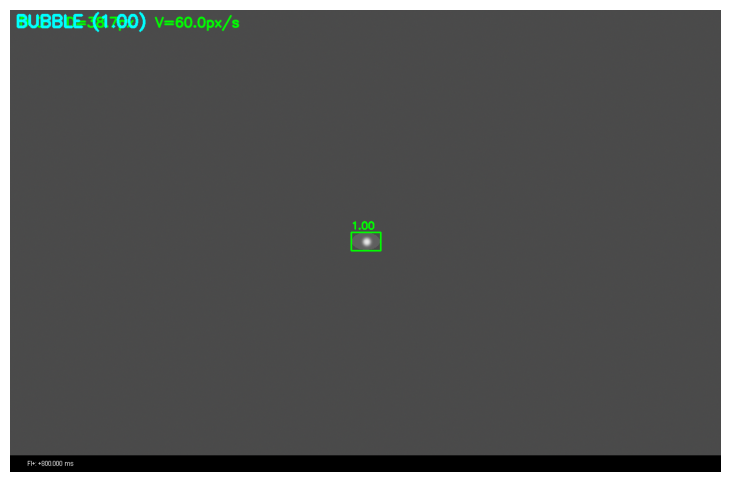

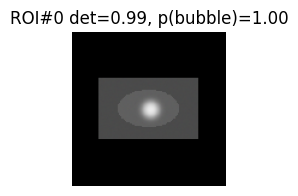

#00 box=[614, 400, 667, 433] det=0.995 → p(bubble)=0.998


In [6]:
# ────────────────────────────────────────────────────────────────────────────────
# Full detect + classify pipeline in one cell
# ────────────────────────────────────────────────────────────────────────────────

import cv2, numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import torch.nn.functional as F

from detectron2.config       import get_cfg
from detectron2.engine       import DefaultPredictor
from detectron2 import model_zoo

# ── 0) CONFIGURE PATHS ─────────────────────────────────────────────────────────
MASKRCNN_WEIGHTS = "C:/BLENDER/BubbleID/Code/Models/Bubblina/model_final.pth"
CNN_WEIGHTS      = "CNN/Bubblina/bubble_classifier.pth"

# ── 1) SET UP Mask R-CNN PREDICTOR ─────────────────────────────────────────────
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(
    "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
))
cfg.MODEL.ROI_HEADS.NUM_CLASSES       = 1        # only “bubble”
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5      # minimum detection score
cfg.MODEL.WEIGHTS                     = MASKRCNN_WEIGHTS
cfg.INPUT.MIN_SIZE_TEST               = 800      # adjust for your data
cfg.INPUT.MAX_SIZE_TEST               = 1333
predictor = DefaultPredictor(cfg)

# ── 2) LOAD 128×128 CNN CLASSIFIER ─────────────────────────────────────────────
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classifier = torch.load(CNN_WEIGHTS, map_location=device)
classifier.to(device).eval()

# ── 3) HELPERS: letterbox & box-expansion ──────────────────────────────────────
def letterbox_no_upscale(pil_img, size=128):
    w,h   = pil_img.size
    scale = min(1.0, size / max(w,h))
    nw,nh = int(w*scale), int(h*scale)
    resized = pil_img.resize((nw,nh), Image.BILINEAR)
    canvas  = Image.new("RGB",(size,size),(0,0,0))
    pad_x, pad_y = (size-nw)//2, (size-nh)//2
    canvas.paste(resized,(pad_x,pad_y))
    return canvas

def expand_box(box, frame_shape, pad_frac=0.3):
    H,W = frame_shape[:2]
    x0,y0,x1,y1 = [int(v) for v in box]
    bw, bh      = x1-x0, y1-y0
    dx, dy      = int(bw*pad_frac), int(bh*pad_frac)
    return [
        max(0,   x0-dx),
        max(0,   y0-dy),
        min(W,   x1+dx),
        min(H,   y1+dy),
    ]

# ── 4) CNN PREPROCESS (just normalize) ─────────────────────────────────────────
to_tensor_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225]),
])

# ── 5) DETECT & CLASSIFY FUNCTION ──────────────────────────────────────────────
def detect_and_classify(frame,
                        det_thresh=0.5,
                        cls_thresh=0.5):
    """
    Returns:
      vis        : BGR image annotated with boxes + frame label
      results    : list of (box, det_score, p_bubble)
      roi_patches: list of (PIL 128×128 ROI, det_score, p_bubble)
    """
    vis    = frame.copy()
    inst   = predictor(frame)["instances"].to("cpu")
    boxes  = inst.pred_boxes.tensor.numpy()
    scores = inst.scores.numpy()

    results    = []
    roi_patches = []

    for box, sc in zip(boxes, scores):
        if sc < det_thresh:
            continue

        # 5.1) expand and crop on original frame
        x0,y0,x1,y1 = expand_box(box, frame.shape, pad_frac=0.3)
        crop = frame[y0:y1, x0:x1]

        # 5.2) letterbox to 128×128 for CNN
        pil_roi = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        roi128   = letterbox_no_upscale(pil_roi, size=128)

        # 5.3) classify
        x = to_tensor_norm(roi128).unsqueeze(0).to(device)
        with torch.no_grad():
            logit = classifier(x)
            probs = F.softmax(logit, dim=1)[0]   # [p(bubble), p(not_bubble)]
            p_bubble = probs[0].item()          # <-- use index 0!
        results.append((box, sc, p_bubble))
        roi_patches.append((roi128, sc, p_bubble))

        # 5.4) draw the detection box and CNN‐score
        col = (0,255,0) if p_bubble>cls_thresh else (0,0,255)
        x0i,y0i,x1i,y1i = map(int, box)
        cv2.rectangle(vis, (x0i,y0i),(x1i,y1i), col, 2)
        cv2.putText(vis, f"{p_bubble:0.2f}",
                    (x0i, y0i-6),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, col, 2)

    # 5.5) frame‐level decision
    max_p = max((p for *_ ,p in results), default=0.0)
    lab  = "BUBBLE" if max_p>cls_thresh else "NO BUBBLE"
    cv2.putText(vis,
                f"{lab} ({max_p:.2f})",
                (10,30),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0, (255,255,0), 3)

    return vis, results, roi_patches

# ── 6) RUN ON A SINGLE FRAME & VISUALIZE ──────────────────────────────────────
frame = cv2.imread(r"C:/BLENDER/BubbleID/Code/synthetic_dataset/val/images/00024.png")
annotated, results, rois = detect_and_classify(
    frame,
    det_thresh=0.5,
    cls_thresh=0.3
)

# (a) show the full annotated frame
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# (b) show each 128×128 ROI the CNN saw
for i,(roi_im, det_s, cls_p) in enumerate(rois):
    plt.figure(figsize=(2,2))
    plt.imshow(roi_im)
    plt.axis("off")
    plt.title(f"ROI#{i} det={det_s:.2f}, p(bubble)={cls_p:.2f}")
    plt.show()

# (c) print out the numeric results
for i,(box, det_s, cls_p) in enumerate(results):
    b = list(map(int,box))
    print(f"#{i:02d} box={b} det={det_s:.3f} → p(bubble)={cls_p:.3f}")

# ────────────────────────────────────────────────────────────────────────────────

In [40]:
import torch

# 1)  Path to the full pickled model you already have
FULL_PICKLE_PATH = "CNN/bubble_classifier.pth"

# 2)  Path where you want the new state-dict file
STATE_DICT_PATH  = "CNN/bubble_classifier_sd.pt"

# -------------------------------------------------------------------------
# Load the full object (unsafe but OK once, because you trust your own file)
model = torch.load(FULL_PICKLE_PATH, map_location="cpu")

# OPTIONAL: sanity-check an image before saving, if you like
# ...

# Save **only** the parameter tensors (state_dict)
torch.save(model.state_dict(), STATE_DICT_PATH)
print(f"✅  exported state-dict → {STATE_DICT_PATH}")


✅  exported state-dict → CNN/bubble_classifier_sd.pt


C:\Users\Lab_Staff\AppData\Local\Temp\ipykernel_9888\273968800.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(FULL_PICKLE_PATH, map_location="cpu")


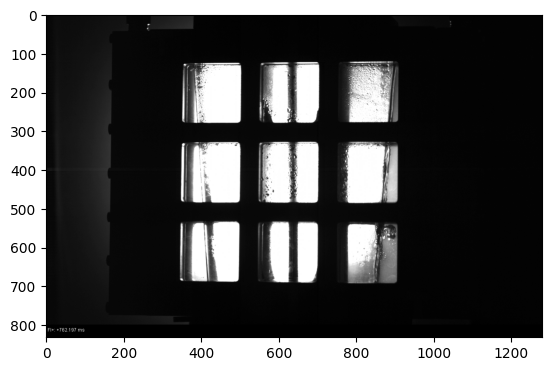

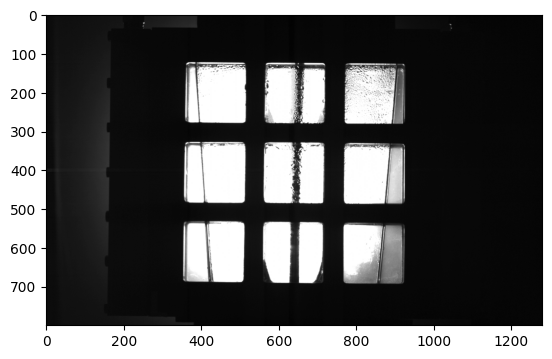

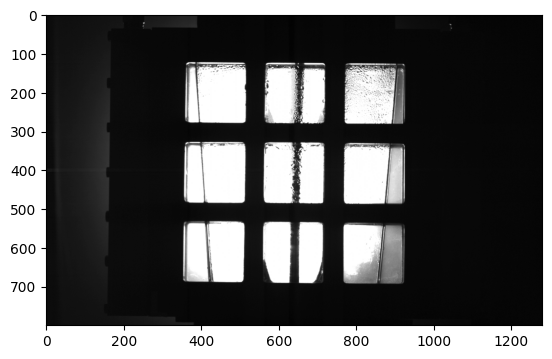

In [4]:
import matplotlib.pyplot as plt
image_path = './output/val/bubble/Img000090.bmp'
plt.imshow(Image.open(image_path))
plt.show()
image_path= './output/val/not_bubble/Img000001.bmp'
plt.imshow(Image.open(image_path))
plt.show()
image_path ='./output/val/not_bubble/Img000001.bmp'
plt.imshow(Image.open(image_path))
plt.show()

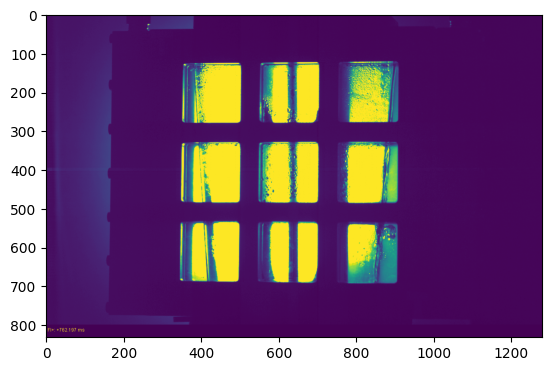

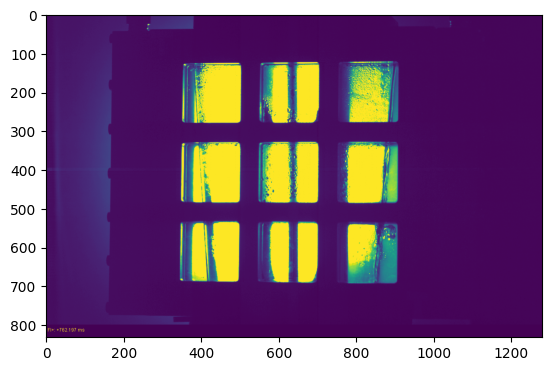

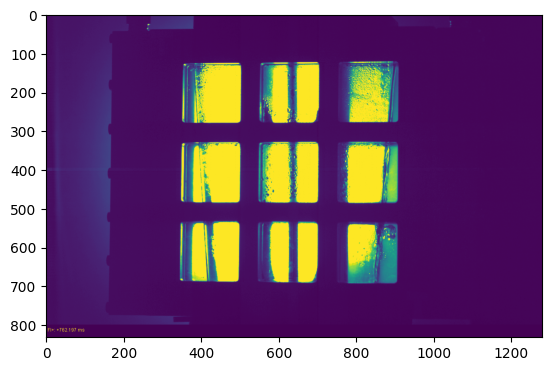

255 255 255


In [8]:
import numpy as np
image_path = './output/val/bubble/Img000090.bmp'

plt.imshow(np.array(Image.open(image_path))[:,:,0])
plt.show()
plt.imshow(np.array(Image.open(image_path))[:,:,1])
plt.show()
plt.imshow(np.array(Image.open(image_path))[:,:,2])
plt.show()
print(np.amax(np.array(Image.open(image_path))[:,:,0]),
     np.amax(np.array(Image.open(image_path))[:,:,1]),
     np.amax(np.array(Image.open(image_path))[:,:,2]))

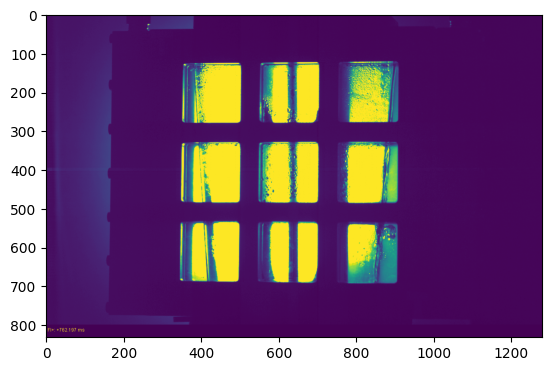

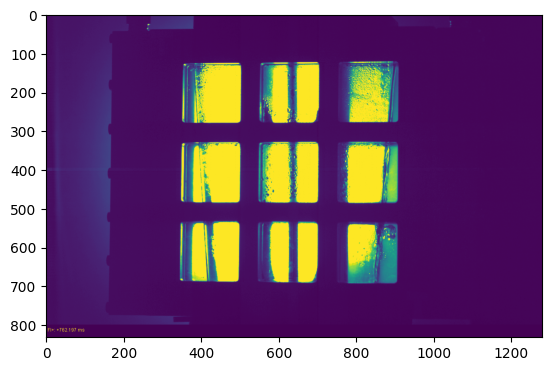

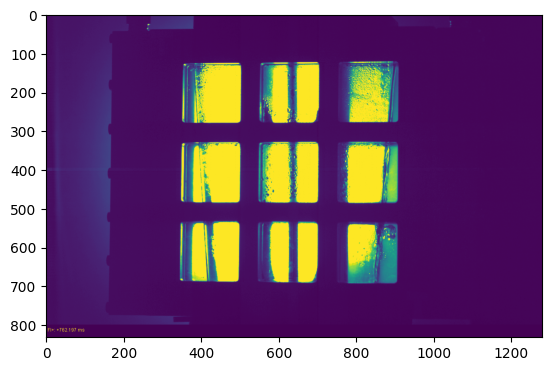

255 255 255


In [14]:
image_path ='./output/val/bubble/Img000090.bmp'
plt.imshow(np.array(Image.open(image_path))[:,:,0])
plt.show()
plt.imshow(np.array(Image.open(image_path))[:,:,1])
plt.show()
plt.imshow(np.array(Image.open(image_path))[:,:,2])
plt.show()
print(np.amax(np.array(Image.open(image_path))[:,:,0]),
     np.amax(np.array(Image.open(image_path))[:,:,1]),
     np.amax(np.array(Image.open(image_path))[:,:,2]))

In [9]:
np.array(Image.open(image_path))[:,:,2]

array([[9, 8, 8, ..., 5, 3, 4],
       [8, 9, 9, ..., 4, 3, 4],
       [9, 9, 8, ..., 4, 4, 4],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

Negative Image Script
=====================
Short Description:
This script removes specific labeled regions (e.g., bubbles) from a set of images using masks, then saves the cleaned images to a new folder.

To Use with a Different Dataset or Output Location, Change These:

1. Input image folder:
   IMG_DIR = r"path/to/input/images.jpg"
   → Change this to the folder containing your input .jpg images.

2. Mask image folder:
   MASK_DIR = r"path/to/pixel/masks.png"
   → Change this to the folder containing your labeled mask images.

3. Output folder for cleaned images:
   OUT_DIR = r"path/to/save/output/images.jpg"
   → Change this to where you want the processed images to be saved.

4. Image file extension (if different):
   IMG_EXT = ".jpg"
   → Change to match the format of your input images (e.g., ".png", ".bmp").

5. Inpainting and dilation settings:
   DILATE_PIXELS    = 3               # Number of pixels to dilate around the mask
   INPAINT_RADIUS   = 3               # Radius for inpainting
   INPAINT_METHOD   = cv2.INPAINT_TELEA  # Use cv2.INPAINT_NS for Navier-Stokes method

What it does:
- Loads each image and its corresponding mask.
- Identifies regions labeled with class value 1 in the mask.
- Optionally dilates and cleans mask edges.
- Uses OpenCV’s inpainting to remove the labeled area from the image.
- Saves the result to the output folder.


In [2]:
import os, re, cv2, numpy as np

IMG_DIR  = r"C:/BLENDER/BubbleID/Code/Bubblina/Frames"
MASK_DIR = r"C:/BLENDER/BubbleID/Code/Bubblina/PixelLabelData"
OUT_DIR  = r"C:/BLENDER/BubbleID/Code/CNN/Neg_Bubblina"
os.makedirs(OUT_DIR, exist_ok=True)

IMG_EXT        = ".jpg"
DILATE_PIXELS  = 3
INPAINT_RADIUS = 3
INPAINT_METHOD = cv2.INPAINT_TELEA

pattern = re.compile(r"^Label_\d+_(frame_\d+)\.(png|bmp|tif|tiff|jpg|jpeg)$", re.IGNORECASE)
kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*DILATE_PIXELS+1,)*2)

# 1) group masks by frame id
by_frame = {}
for fn in os.listdir(MASK_DIR):
    m = pattern.match(fn)
    if not m:
        continue
    frame_id = m.group(1)  # "frame_3756"
    by_frame.setdefault(frame_id, []).append(os.path.join(MASK_DIR, fn))

total = 0
done  = 0

# 2) process each frame once
for frame_id, mask_paths in sorted(by_frame.items()):
    img_path = os.path.join(IMG_DIR, frame_id + IMG_EXT)
    if not os.path.isfile(img_path):
        print(f"image missing for {frame_id}; skipping")
        continue

    img = cv2.imread(img_path)
    if img is None:
        print(f"could not read image for {frame_id}")
        continue

    # build a combined binary mask (any value > 0 counts as bubble)
    combined = np.zeros(img.shape[:2], np.uint8)
    for mp in mask_paths:
        m = cv2.imread(mp, cv2.IMREAD_UNCHANGED)
        if m is None:
            print("could not read mask", mp)
            continue
        if m.ndim == 3:
            mg = cv2.cvtColor(m, cv2.COLOR_BGR2GRAY)
        else:
            mg = m
        combined |= (mg > 0).astype(np.uint8) * 255

    if np.count_nonzero(combined) == 0:
        # nothing to inpaint; just copy the frame
        out_path = os.path.join(OUT_DIR, frame_id + IMG_EXT)
        cv2.imwrite(out_path, img)
        done += 1
        total += 1
        continue

    # optional dilation/cleanup
    if DILATE_PIXELS:
        combined = cv2.dilate(combined, kernel, iterations=7)
        combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel, iterations=3)

    clean = cv2.inpaint(img, combined, INPAINT_RADIUS, INPAINT_METHOD)
    out_path = os.path.join(OUT_DIR, frame_id + IMG_EXT)
    cv2.imwrite(out_path, clean)
    done  += 1
    total += 1

print(f"Finished. Wrote {done}/{total} negatives to: {OUT_DIR}")


image missing for frame_3785; skipping
image missing for frame_3786; skipping
image missing for frame_3787; skipping
image missing for frame_3788; skipping
image missing for frame_3789; skipping
image missing for frame_3790; skipping
image missing for frame_3791; skipping
image missing for frame_3792; skipping
image missing for frame_3793; skipping
image missing for frame_3794; skipping
image missing for frame_3795; skipping
image missing for frame_3796; skipping
image missing for frame_3797; skipping
image missing for frame_3798; skipping
image missing for frame_3799; skipping
image missing for frame_3800; skipping
image missing for frame_3801; skipping
image missing for frame_3802; skipping
image missing for frame_3803; skipping
image missing for frame_3804; skipping
Finished. Wrote 80/80 negatives to: C:/BLENDER/BubbleID/Code/CNN/Neg_Bubblina


In [13]:
import os, re, cv2, numpy as np

# ───────── USER SETTINGS ─────────
REF_FRAME_PATH = r"C:/BLENDER/BubbleID/Code/Bubblina/frame_200.jpg"
MASK_DIR       = r"C:/BLENDER/BubbleID/Code/Bubblina/PixelLabelData"   # Label_*_frame_####.png
OUT_DIR        = r"C:/BLENDER/BubbleID/Code/CNN/Cropped128_Bubblina_not_bubble"
SAVE_CLEAN_REF = True
CLEAN_REF_PATH = r"C:/BLENDER/BubbleID/Code/CNN/cleaned_reference.jpg"

PATCH          = 128          # crop size
ELLIPTICAL_PASTE = True       # True = paste inside ellipse; False = paste whole rectangle
TILE_DONOR       = True       # True = tile donor (keeps texture sharp); False = resize donor to ROI
LUMA_MATCH       = False      # True = shift donor brightness to match a small ring around ROI
RING_FOR_LUMA    = 6          # pixels around ROI for luma matching
PAD              = 40         # reflect padding for safe pastes at borders
MIN_AREA         = 10         # skip tiny mask specks when cropping
# mask name pattern: Label_7_frame_3756.png  → captures "frame_3756"
MASK_PAT = re.compile(r"^Label_\d+_(frame_\d+)\.(png|bmp|tif|tiff|jpg|jpeg)$", re.IGNORECASE)
# ─────────────────────────────────

os.makedirs(OUT_DIR, exist_ok=True)

def crop_with_reflect(frame, cx, cy, size=PATCH):
    h, w = frame.shape[:2]
    x0 = int(cx - size//2); y0 = int(cy - size//2)
    x1 = x0 + size;         y1 = y0 + size
    pad_left   = max(0, -x0); pad_top    = max(0, -y0)
    pad_right  = max(0, x1 - w); pad_bottom = max(0, y1 - h)
    if pad_left or pad_top or pad_right or pad_bottom:
        frame = cv2.copyMakeBorder(frame, pad_top, pad_bottom, pad_left, pad_right,
                                   borderType=cv2.BORDER_REFLECT_101)
        x0 += pad_left; x1 += pad_left; y0 += pad_top; y1 += pad_top
    return frame[y0:y1, x0:x1]

def tile_to_size(img, w, h):
    H, W = img.shape[:2]
    reps_y = max(1, int(np.ceil(h / H)))
    reps_x = max(1, int(np.ceil(w / W)))
    big = np.tile(img, (reps_y, reps_x, 1))
    return big[:h, :w].copy()

def luma_of_ring(image_pad, center, axes, ring_px):
    # ring around the ellipse on the padded image
    hard = np.zeros(image_pad.shape[:2], np.uint8)
    cv2.ellipse(hard, center, axes, 0, 0, 360, 255, -1)
    ksz = max(1, 2*ring_px+1)
    erode_k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksz, ksz))
    inner = cv2.erode(hard, erode_k, iterations=1)
    ring  = cv2.subtract(hard, inner)
    ring_idx = np.where(ring > 0)
    if ring_idx[0].size == 0:
        return float(cv2.cvtColor(image_pad, cv2.COLOR_BGR2GRAY).mean())
    return float(cv2.cvtColor(image_pad, cv2.COLOR_BGR2GRAY)[ring_idx].mean())

def shift_luma(img, target_mean):
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    delta = target_mean - float(g.mean())
    out = np.clip(img.astype(np.float32) + delta, 0, 255).astype(np.uint8)
    return out

# 1) load reference
ref = cv2.imread(REF_FRAME_PATH)
assert ref is not None, f"Could not read reference: {REF_FRAME_PATH}"
ref_clean = ref.copy()
H, W = ref.shape[:2]

# 2) choose donor background
print("Draw ONE donor box (background to copy). ENTER to accept, ESC to skip.")
donor_box = cv2.selectROI("Donor background", ref, fromCenter=False, showCrosshair=True)
cv2.destroyWindow("Donor background")
dx, dy, dw, dh = map(int, donor_box)
donor = ref[dy:dy+dh, dx:dx+dw].copy() if (dw > 0 and dh > 0) else ref.copy()

# 3) select MULTIPLE bubbles (loop selectROI)
print("Draw a bubble box, ENTER to accept. Repeat for more. ESC when DONE.")
rois = []
preview = ref.copy()
while True:
    box = cv2.selectROI("Select bubbles (ESC to finish)", preview, fromCenter=False, showCrosshair=True)
    x, y, w, h = map(int, box)
    if w <= 0 or h <= 0:
        cv2.destroyWindow("Select bubbles (ESC to finish)")
        break
    rois.append((x, y, w, h))
    cv2.rectangle(preview, (x, y), (x+w, y+h), (0,255,0), 2)

print(f"ROIs captured: {len(rois)}")

# 4) HARD-PASTE donor onto each ROI
dst_pad = cv2.copyMakeBorder(ref_clean, PAD, PAD, PAD, PAD, cv2.BORDER_REFLECT_101)
for (x, y, w, h) in rois:
    x0, y0 = x + PAD, y + PAD
    # donor texture for this ROI
    donor_tex = tile_to_size(donor, w, h) if TILE_DONOR else cv2.resize(donor, (w, h), cv2.INTER_LINEAR)

    if LUMA_MATCH:
        center = (x + w//2 + PAD, y + h//2 + PAD)
        axes   = (max(1, w//2), max(1, h//2))
        target_mean = luma_of_ring(dst_pad, center, axes, RING_FOR_LUMA)
        donor_tex = shift_luma(donor_tex, target_mean)

    if ELLIPTICAL_PASTE:
        # paste only inside ellipse
        center = (x + w//2 + PAD, y + h//2 + PAD)
        axes   = (max(1, w//2), max(1, h//2))
        mask = np.zeros(dst_pad.shape[:2], np.uint8)
        cv2.ellipse(mask, center, axes, 0, 0, 360, 255, -1)
        m_roi = mask[y0:y0+h, x0:x0+w][..., None]  # HxWx1
        dst_roi = dst_pad[y0:y0+h, x0:x0+w]
        dst_pad[y0:y0+h, x0:x0+w] = np.where(m_roi > 0, donor_tex, dst_roi)
    else:
        # paste whole rectangle
        dst_pad[y0:y0+h, x0:x0+w] = donor_tex

ref_clean = dst_pad[PAD:-PAD, PAD:-PAD]

if SAVE_CLEAN_REF:
    cv2.imwrite(CLEAN_REF_PATH, ref_clean)
    print("Saved cleaned reference to:", CLEAN_REF_PATH)

# 5) Use ALL mask files only for crop coordinates; crop from ref_clean
def save_crops_from_masks(clean_img):
    saved = 0
    for fn in sorted(os.listdir(MASK_DIR)):
        m = MASK_PAT.match(fn)
        if not m:
            continue
        frame_id = m.group(1)  # e.g., frame_3756
        mp = os.path.join(MASK_DIR, fn)
        mm = cv2.imread(mp, cv2.IMREAD_UNCHANGED)
        if mm is None:
            print("Could not read mask:", mp)
            continue
        if mm.ndim == 3:
            mm = cv2.cvtColor(mm, cv2.COLOR_BGR2GRAY)
        bin_mask = (mm > 0).astype(np.uint8)
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
        bin_mask = cv2.morphologyEx(bin_mask, cv2.MORPH_OPEN,  k, iterations=1)
        bin_mask = cv2.morphologyEx(bin_mask, cv2.MORPH_CLOSE, k, iterations=1)
        contours, _ = cv2.findContours(bin_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for idx, cnt in enumerate(contours, start=1):
            if cv2.contourArea(cnt) < MIN_AREA:
                continue
            M = cv2.moments(cnt)
            if M["m00"] == 0:
                continue
            cx = int(M["m10"]/M["m00"]); cy = int(M["m01"]/M["m00"])
            patch = crop_with_reflect(clean_img, cx, cy, PATCH)
            cv2.imwrite(os.path.join(OUT_DIR, f"{frame_id}_{idx}.png"), patch)
            saved += 1
    print(f"Saved {saved} crops from cleaned reference → {OUT_DIR}")

save_crops_from_masks(ref_clean)
cv2.destroyAllWindows()


Draw ONE donor box (background to copy). ENTER to accept, ESC to skip.
Draw a bubble box, ENTER to accept. Repeat for more. ESC when DONE.
ROIs captured: 3
Saved cleaned reference to: C:/BLENDER/BubbleID/Code/CNN/cleaned_reference.jpg
Saved 1235 crops from cleaned reference → C:/BLENDER/BubbleID/Code/CNN/Cropped128_Bubblina_not_bubble


Image Cropper
============
Short Description:
This script extracts 128x128 image patches centered on each labeled region (bubble) from input images using the corresponding mask files, and saves them as individual cropped images.

To Use with a Different Dataset or Output Location, Change These:

1. Input image folder:
   IMG_DIR = r"path/to/input/images"
   → Folder with the full-size input images.

2. Mask image folder:
   MASK_DIR = r"path/to/pixel/masks"
   → Folder with mask images (.png) indicating where the bubbles are.

3. Output folder for cropped patches:
   OUT_DIR = r"path/to/save/location"
   → This is where the 128x128 cropped patches will be saved.

4. Patch size (if needed):
   PATCH = 128
   → Change this if you want a different output crop size.

What it does:
- Loads each image and its corresponding binary mask.
- Finds all connected regions (bubbles) in the mask.
- Calculates the centroid of each region.
- Crops a 128x128 patch centered on each centroid (with reflect-padding if needed).
- Saves each cropped patch as a separate PNG in the output folder.


In [3]:
import os
import re
import cv2
import numpy as np

# ── 1) CONFIGURE YOUR PATHS ─────────────────────────────────────────────
IMG_DIR  = r"C:/BLENDER/BubbleID/Code/Bubblina/Validation Frames"        
MASK_DIR = r"C:/BLENDER/BubbleID/Code/Bubblina/PixelLabelData"  
OUT_DIR  = r"C:/BLENDER/BubbleID/Code/CNN/Cropped128_Bubblina_val_Bubble"  
os.makedirs(OUT_DIR, exist_ok=True)

# ── 2) PARAMETERS ────────────────────────────────────────────────────────
PATCH = 128                # output patch size
HALF  = PATCH // 2         # half‐width, for centering

# ── 3) HELPERS ───────────────────────────────────────────────────────────
def crop_with_reflect(frame, cx, cy, size=PATCH):
    """
    Extract a size×size crop centered on (cx,cy).
    If the window runs off the image borders, reflect‐pad as needed.
    """
    h, w = frame.shape[:2]
    x0 = int(cx - size//2)
    y0 = int(cy - size//2)
    x1 = x0 + size
    y1 = y0 + size

    # compute needed padding
    pad_left   = max(0, -x0)
    pad_top    = max(0, -y0)
    pad_right  = max(0, x1 - w)
    pad_bottom = max(0, y1 - h)

    # reflect‐pad if any side goes out of bounds
    if pad_left or pad_top or pad_right or pad_bottom:
        frame = cv2.copyMakeBorder(
            frame,
            pad_top, pad_bottom,
            pad_left, pad_right,
            borderType=cv2.BORDER_REFLECT_101
        )
        x0 += pad_left
        x1 += pad_left
        y0 += pad_top
        y1 += pad_top

    return frame[y0:y1, x0:x1]

# ── 4) MAIN LOOP ────────────────────────────────────────────────────────
# regex to pull "frame_3750" from "Label_1_frame_3750.png"
pattern = re.compile(r"^Label_\d+_(frame_\d+)\.png$", re.IGNORECASE)


for mask_fn in sorted(os.listdir(MASK_DIR)):
    # only process PNG mask files
    if not mask_fn.lower().endswith('.png'):
        continue

    m = pattern.match(mask_fn)
    if not m:
        print(f"skipping unexpected filename: {mask_fn}")
        continue

    stem = m.group(1)  # e.g. "FancyAnt_80_frame_0002"
    img_path  = os.path.join(IMG_DIR,  stem + ".jpg")
    mask_path = os.path.join(MASK_DIR, mask_fn)

    # check existence
    if not os.path.isfile(img_path):
        print(f"missing frame for {stem}, skipping")
        continue

    # load frame & mask
    img  = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if img is None or mask is None:
        print(f"could not load frame or mask for {stem}")
        continue

    # binarize mask (bubble pixels > 0)
    bin_mask = (mask > 0).astype(np.uint8)

    # find each connected bubble contour
    contours, _ = cv2.findContours(
        bin_mask, 
        cv2.RETR_EXTERNAL, 
        cv2.CHAIN_APPROX_SIMPLE
    )

    # crop one patch per bubble
    for idx, cnt in enumerate(contours, start=1):
        # compute centroid via image moments
        M = cv2.moments(cnt)
        if M["m00"] == 0:
            continue
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        # reflect‐pad & crop
        patch = crop_with_reflect(img, cx, cy, PATCH)

        # save as PNG: <stem>_1.png, <stem>_2.png, …
        out_name = f"{stem}_{idx}.png"
        cv2.imwrite(os.path.join(OUT_DIR, out_name), patch)

print("Done cropping positives →", OUT_DIR)

missing frame for frame_3849, skipping
missing frame for frame_3759, skipping
missing frame for frame_3760, skipping
missing frame for frame_3761, skipping
missing frame for frame_3762, skipping
missing frame for frame_3763, skipping
missing frame for frame_3764, skipping
missing frame for frame_3765, skipping
missing frame for frame_3766, skipping
missing frame for frame_3767, skipping
missing frame for frame_3768, skipping
missing frame for frame_3750, skipping
missing frame for frame_3769, skipping
missing frame for frame_3770, skipping
missing frame for frame_3771, skipping
missing frame for frame_3772, skipping
missing frame for frame_3773, skipping
missing frame for frame_3774, skipping
missing frame for frame_3775, skipping
missing frame for frame_3776, skipping
missing frame for frame_3777, skipping
missing frame for frame_3778, skipping
missing frame for frame_3751, skipping
missing frame for frame_3779, skipping
missing frame for frame_3780, skipping
missing frame for frame_3